In [1]:
# pgf_backend = True
pgf_backend = False
figure_str = "paper_"


import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler

if pgf_backend:
    mpl.use("pgf")

In [2]:
import sys

sys.path.append("../../src/")


import pickle

from lightning import seed_everything

In [3]:
# IEEE Access matplotlib settings
# Source: https://journals.ieeeauthorcenter.ieee.org/create-your-ieee-journal-article/create-graphics-for-your-article/resolution-and-size/

font_size = 8

markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "P",
    "X",
    "*",
    "<",
    ">",
    "p",
    "h",
    "H",
    "d",
    "|",
    "_",
    "1",
    "2",
    "3",
    "4",
    "+",
    "x",
    ".",
    ",",
]
colors = list(mpl.colormaps["tab10"].colors) * ((len(markers) // 10) + 1)
colors = colors[: len(markers)]

plt.rcParams.update(
    {
        "pgf.rcfonts": False,  # don't use matplotlib defaults
        "pgf.texsystem": "lualatex",  # use LuaLaTeX
        "font.family": "serif",
        "font.serif": ["Times New Roman"],  # system Times New Roman
        "figure.dpi": 300,
        "font.size": font_size,
        "axes.titlesize": font_size,
        "figure.titlesize": font_size,
        "axes.labelsize": font_size,
        "legend.fontsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "pgf.preamble": r"\usepackage{fontspec}\setmainfont{Times New Roman}",
        "axes.prop_cycle": cycler(color=colors)
        + cycler(marker=markers)
        + cycler(markevery=[10] * len(markers)),
        "lines.markersize": 3,
        "lines.markeredgewidth": 0.0,
    }
)

# IEEE standard widths (inches)
linewidth_singlecol = 3.5  # single-column figure
linewidth_doublecol = 7.16  # double-column figure
max_height = 9.25  # max text height

golden_ratio = (5**0.5 - 1) / 2

dpi = 300


def set_size(width=linewidth_singlecol, ratio=golden_ratio, height_pad=0):
    height = width * ratio + height_pad
    return (width, min(height, max_height))

In [4]:
seed_everything(0)

Seed set to 0


0

In [5]:
models_dict = []

In [ ]:
file_paths = [
    "../evaluate_models/results/metric_evaluation/NaiveHS.pkl",
    "../evaluate_models/results/metric_evaluation/DDNN_Ens.pkl",
    "../evaluate_models/results/metric_evaluation/MCD.pkl",
    "../evaluate_models/results/metric_evaluation/EvDNN.pkl",
    "../evaluate_models/results/metric_evaluation/DDNN_CP.pkl",
    "../evaluate_models/results/metric_evaluation/Ens_CP.pkl",
    "../evaluate_models/results/metric_evaluation/MCD_CP.pkl",
    "../evaluate_models/results/metric_evaluation/EvDNN_CP.pkl",
    "../evaluate_models/results/metric_evaluation/LEAR_GARCH.pkl",
    "../evaluate_models/results/metric_evaluation/LEAR_QRA.pkl",
    "../evaluate_models/results/metric_evaluation/LEAR_CP.pkl",
    "../evaluate_models/results/metric_evaluation/XGBoost_GARCH.pkl",
    "../evaluate_models/results/metric_evaluation/XGBoost_QRA.pkl",
    "../evaluate_models/results/metric_evaluation/XGBoost_CP.pkl",
]


class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        try:
            return super().find_class(module, name)
        except (AttributeError, ModuleNotFoundError):
            # Return a dummy class for missing classes
            return type(name, (), {})


for file_path in file_paths:
    with open(file_path, "rb") as f:
        models_dict.extend(CustomUnpickler(f).load())


In [7]:
for model in models_dict:
    print(model["model_name"])

naive_hs_train_normal
naive_hs_val_normal
ddnn_normal
ens5_normal
ens10_normal
mcd10_normal
mcd30_normal
evdnn_normal
DDNN-CP
Ens10-CP
MCD30-CP
EvDNN-CP
LEAR_GARCH
LEAR_QRA
LEAR-CP
XGBoost_GARCH
XGBoost_QRA
XGBoost-CP


In [8]:
for model in models_dict:
    if model["model_name"] == "ddnn_normal":
        model["model_name"] = "DDNN"
    elif model["model_name"] == "ens5_normal":
        model["model_name"] = "Ens5"
    elif model["model_name"] == "ens10_normal":
        model["model_name"] = "Ens10"
    elif model["model_name"] == "mcd10_normal":
        model["model_name"] = "MCD10"
    elif model["model_name"] == "mcd30_normal":
        model["model_name"] = "MCD30"
    elif model["model_name"] == "naive_hs_train_normal":
        model["model_name"] = "Naive-HS$_{train}$"
    elif model["model_name"] == "naive_hs_val_normal":
        model["model_name"] = "Naive-HS$_{val}$"
    elif model["model_name"] == "evdnn_normal":
        model["model_name"] = "EvDNN"
    elif model["model_name"] == "lasso_garch":
        model["model_name"] = "LASSO-GARCH"
    elif model["model_name"] == "LEAR_GARCH":
        model["model_name"] = "LEAR-GARCH"
    elif model["model_name"] == "LEAR_QRA":
        model["model_name"] = "LEAR-QRA"
    elif model["model_name"] == "XGBoost_GARCH":
        model["model_name"] = "XGBoost-GARCH"
    elif model["model_name"] == "XGBoost_QRA":
        model["model_name"] = "XGBoost-QRA"

    if "ece" in model.keys():
        model["maace"] = model["ece"]
        model["maace_std"] = model["ece_std"]

    model["maace"] = model["maace"] * 100
    model["maace_std"] = model["maace_std"] * 100
    model["MAE"] = model["mae"]
    model["MAE std"] = model["mae_std"]
    model["RMSE"] = model["rmse"]
    model["RMSE std"] = model["rmse_std"]
    model["CRPS$_{1:99:1}$"] = model["crps"]
    model["CRPS$_{1:99:1}$ std"] = model["crps_std"]
    model["MAACE$_{2:98:2}$"] = model["maace"]
    model["MAACE$_{2:98:2}$ std"] = model["maace_std"]

In [9]:
metrics = [
    "MAE",
    "MAE std",
    "RMSE",
    "RMSE std",
    "CRPS$_{1:99:1}$",
    "CRPS$_{1:99:1}$ std",
    "MAACE$_{2:98:2}$",
    "MAACE$_{2:98:2}$ std",
]
results = {
    metric: [np.mean(model[metric]) for model in models_dict] for metric in metrics
}

model_names = [model["model_name"] for model in models_dict]
results_df = pd.DataFrame(results, index=model_names)
results_df.round(3)

,MAE,MAE std,RMSE,RMSE std,CRPS$_{1:99:1}$,CRPS$_{1:99:1}$ std,MAACE$_{2:98:2}$,MAACE$_{2:98:2}$ std
Naive-HS$_{train}$,24.878,0.000,36.685,0.000,9.823,0.000,12.842,0.000
Naive-HS$_{val}$,24.878,0.000,36.685,0.000,9.634,0.000,9.107,0.000
DDNN,17.209,0.767,25.684,0.913,6.392,0.286,5.286,2.735
Ens5,16.692,0.464,25.193,0.685,6.276,0.501,2.398,1.080
Ens10,16.577,0.211,24.942,0.262,6.087,0.069,2.370,1.043
MCD10,16.193,0.427,24.549,0.497,5.918,0.163,2.276,1.455
MCD30,16.116,0.412,24.426,0.447,5.897,0.149,1.962,1.379
EvDNN,15.940,0.697,24.566,0.674,7.510,0.311,43.937,0.730
DDNN-CP,17.209,0.767,25.684,0.913,6.330,0.271,1.948,0.361
Ens10-CP,16.577,0.211,24.942,0.262,6.114,0.078,2.272,0.126


In [10]:
print(results_df.round(3).to_latex(float_format="%.3f"))

\begin{tabular}{lrrrrrrrr}
\toprule
 & MAE & MAE std & RMSE & RMSE std & CRPS$_{1:99:1}$ & CRPS$_{1:99:1}$ std & MAACE$_{2:98:2}$ & MAACE$_{2:98:2}$ std \\
\midrule
Naive-HS$_{train}$ & 24.878 & 0.000 & 36.685 & 0.000 & 9.823 & 0.000 & 12.842 & 0.000 \\
Naive-HS$_{val}$ & 24.878 & 0.000 & 36.685 & 0.000 & 9.634 & 0.000 & 9.107 & 0.000 \\
DDNN & 17.209 & 0.767 & 25.684 & 0.913 & 6.392 & 0.286 & 5.286 & 2.735 \\
Ens5 & 16.692 & 0.464 & 25.193 & 0.685 & 6.276 & 0.501 & 2.398 & 1.080 \\
Ens10 & 16.577 & 0.211 & 24.942 & 0.262 & 6.087 & 0.069 & 2.370 & 1.043 \\
MCD10 & 16.193 & 0.427 & 24.549 & 0.497 & 5.918 & 0.163 & 2.276 & 1.455 \\
MCD30 & 16.116 & 0.412 & 24.426 & 0.447 & 5.897 & 0.149 & 1.962 & 1.379 \\
EvDNN & 15.940 & 0.697 & 24.566 & 0.674 & 7.510 & 0.311 & 43.937 & 0.730 \\
DDNN-CP & 17.209 & 0.767 & 25.684 & 0.913 & 6.330 & 0.271 & 1.948 & 0.361 \\
Ens10-CP & 16.577 & 0.211 & 24.942 & 0.262 & 6.114 & 0.078 & 2.272 & 0.126 \\
MCD30-CP & 16.116 & 0.412 & 24.426 & 0.447 & 5.942 & 0.1

In [11]:
quantiles = np.linspace(0.01, 0.99, 99)
confidence_levels = np.flip(
    np.array([quantiles[-i - 1] - quantiles[i] for i in range(len(quantiles) // 2)])
)
confidence_levels

array([0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 , 0.22,
       0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44,
       0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64, 0.66,
       0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86, 0.88,
       0.9 , 0.92, 0.94, 0.96, 0.98])

In [12]:
eval_confidence_levels_indx = [24, 29, 34, 39, 44, 48]
print(confidence_levels[eval_confidence_levels_indx])

[0.5  0.6  0.7  0.8  0.9  0.98]


In [ ]:
results = {
    f"PICP$_{int(confidence_levels[cl_indx] * 100)}%$": [
        model["coverage_mean"][cl_indx] * 100 for model in models_dict
    ]
    for cl_indx in eval_confidence_levels_indx
}
# results = {
#     f"PICP$_{int(confidence_levels[cl_indx]*100)}%$": [
#         model["coverage_std"][cl_indx] * 100 for model in models_dict
#     ]
#     for cl_indx in eval_confidence_levels_indx
# }

model_names = [model["model_name"] for model in models_dict]
results_df = pd.DataFrame(results, index=model_names)
results_df.round(2)

,PICP$_50%$,PICP$_60%$,PICP$_70%$,PICP$_80%$,PICP$_90%$,PICP$_98%$
Naive-HS$_{train}$,67.93,75.20,81.88,87.65,93.89,98.82
Naive-HS$_{val}$,63.55,71.00,77.87,84.10,90.36,97.29
DDNN,44.24,53.21,62.28,71.54,81.47,91.47
Ens5,47.67,57.09,66.58,75.89,85.60,94.35
Ens10,47.63,57.13,66.48,75.93,85.83,94.60
MCD10,47.34,56.85,66.49,76.47,86.90,95.71
MCD30,47.63,57.27,66.92,76.89,87.36,95.98
EvDNN,4.84,6.13,7.63,9.82,13.42,22.17
DDNN-CP,47.43,57.39,67.32,77.48,87.90,96.78
Ens10-CP,46.98,57.15,67.17,77.31,87.66,96.66


In [14]:
print(results_df.round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrr}
\toprule
 & PICP$_50%$ & PICP$_60%$ & PICP$_70%$ & PICP$_80%$ & PICP$_90%$ & PICP$_98%$ \\
\midrule
Naive-HS$_{train}$ & 67.93 & 75.20 & 81.88 & 87.65 & 93.89 & 98.82 \\
Naive-HS$_{val}$ & 63.55 & 71.00 & 77.87 & 84.10 & 90.36 & 97.29 \\
DDNN & 44.24 & 53.21 & 62.28 & 71.54 & 81.47 & 91.47 \\
Ens5 & 47.67 & 57.09 & 66.58 & 75.89 & 85.60 & 94.35 \\
Ens10 & 47.63 & 57.13 & 66.48 & 75.93 & 85.83 & 94.60 \\
MCD10 & 47.34 & 56.85 & 66.49 & 76.47 & 86.90 & 95.71 \\
MCD30 & 47.63 & 57.27 & 66.92 & 76.89 & 87.36 & 95.98 \\
EvDNN & 4.84 & 6.13 & 7.63 & 9.82 & 13.42 & 22.17 \\
DDNN-CP & 47.43 & 57.39 & 67.32 & 77.48 & 87.90 & 96.78 \\
Ens10-CP & 46.98 & 57.15 & 67.17 & 77.31 & 87.66 & 96.66 \\
MCD30-CP & 47.53 & 57.31 & 67.39 & 77.59 & 88.21 & 96.99 \\
EvDNN-CP & 47.21 & 57.02 & 67.01 & 77.18 & 87.65 & 96.58 \\
LEAR-GARCH & 55.21 & 65.44 & 75.18 & 84.07 & 91.67 & 97.55 \\
LEAR-QRA & 45.13 & 55.05 & 65.61 & 77.89 & 88.63 & 96.65 \\
LEAR-CP & 52.27 & 62.15 & 72.18 & 82.06 

In [ ]:
results = {
    f"MPIW$_{int(confidence_levels[cl_indx] * 100)}%$": [
        model["mpiw_mean"][cl_indx] for model in models_dict
    ]
    for cl_indx in eval_confidence_levels_indx
}
# results = {
#     f"MPIW$_{int(confidence_levels[cl_indx]*100)}%$": [
#         model["mpiw_std"][cl_indx] for model in models_dict
#     ]
#     for cl_indx in eval_confidence_levels_indx
# }

model_names = [model["model_name"] for model in models_dict]
results_df = pd.DataFrame(results, index=model_names)
results_df.round(2)

,MPIW$_50%$,MPIW$_60%$,MPIW$_70%$,MPIW$_80%$,MPIW$_90%$,MPIW$_98%$
Naive-HS$_{train}$,57.14,71.29,87.80,108.56,139.34,197.07
Naive-HS$_{val}$,49.94,62.32,76.74,94.89,121.79,172.25
DDNN,24.10,30.07,37.03,45.78,58.76,83.11
Ens5,26.20,32.31,39.86,52.84,75.12,103.55
Ens10,24.88,31.14,38.54,48.07,62.90,94.10
MCD10,24.41,30.55,37.77,47.00,61.01,88.59
MCD30,24.52,30.69,37.96,47.25,61.39,89.42
EvDNN,2.26,2.87,3.62,4.64,6.41,11.08
DDNN-CP,24.64,31.27,39.51,50.41,66.66,100.51
Ens10-CP,23.08,29.53,37.60,48.40,64.03,96.02


In [16]:
print(results_df.round(2).to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrr}
\toprule
 & MPIW$_50%$ & MPIW$_60%$ & MPIW$_70%$ & MPIW$_80%$ & MPIW$_90%$ & MPIW$_98%$ \\
\midrule
Naive-HS$_{train}$ & 57.14 & 71.29 & 87.80 & 108.56 & 139.34 & 197.07 \\
Naive-HS$_{val}$ & 49.94 & 62.32 & 76.74 & 94.89 & 121.79 & 172.25 \\
DDNN & 24.10 & 30.07 & 37.03 & 45.78 & 58.76 & 83.11 \\
Ens5 & 26.20 & 32.31 & 39.86 & 52.84 & 75.12 & 103.55 \\
Ens10 & 24.88 & 31.14 & 38.54 & 48.07 & 62.90 & 94.10 \\
MCD10 & 24.41 & 30.55 & 37.77 & 47.00 & 61.01 & 88.59 \\
MCD30 & 24.52 & 30.69 & 37.96 & 47.25 & 61.39 & 89.42 \\
EvDNN & 2.26 & 2.87 & 3.62 & 4.64 & 6.41 & 11.08 \\
DDNN-CP & 24.64 & 31.27 & 39.51 & 50.41 & 66.66 & 100.51 \\
Ens10-CP & 23.08 & 29.53 & 37.60 & 48.40 & 64.03 & 96.02 \\
MCD30-CP & 23.05 & 29.27 & 37.06 & 47.21 & 62.91 & 95.61 \\
EvDNN-CP & 22.22 & 28.38 & 35.89 & 45.98 & 61.61 & 93.93 \\
LEAR-GARCH & 23.42 & 29.22 & 35.98 & 44.49 & 57.10 & 80.76 \\
LEAR-QRA & 17.88 & 23.15 & 29.63 & 39.18 & 54.13 & 98.68 \\
LEAR-CP & 20.46 & 25.61 & 31.74 & 

In [17]:
models_to_exclude = {
    "Ens5",
    "MCD10",
    "Naive-HS$_{train}$",
    "EvDNN",
    "EvDNN-CP",
    "MCD30-CP",
    "Ens10-CP",
}
models_dict = [
    model for model in models_dict if model["model_name"] not in models_to_exclude
]

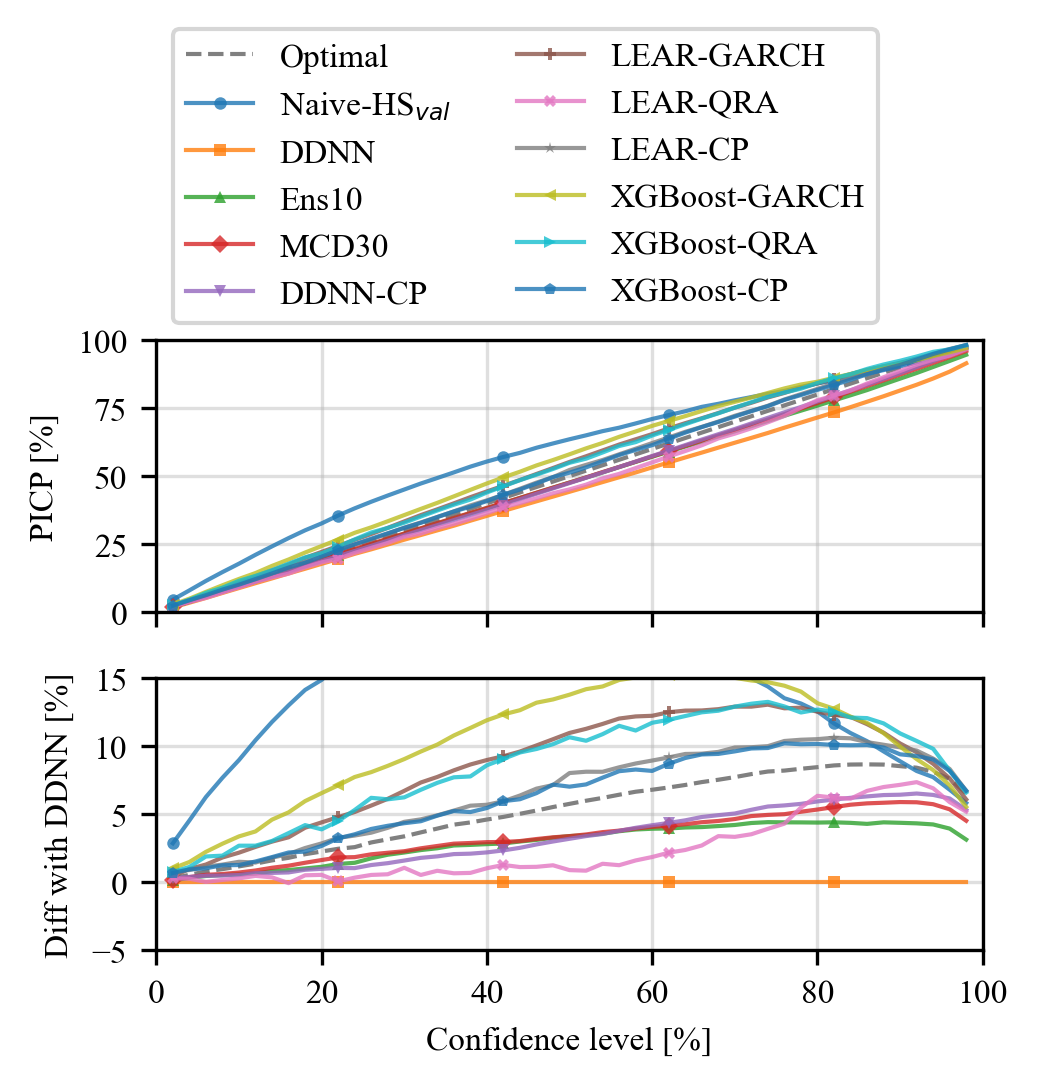

In [18]:
# plot coverage probability
figsize = set_size(height_pad=1.5)
fig, ax = plt.subplots(
    2, 1, figsize=figsize, sharex=True, gridspec_kw={"height_ratios": [1, 1]}
)
lw = 1
ax[0].plot(
    confidence_levels * 100,
    confidence_levels * 100,
    linestyle="--",
    lw=lw,
    color="gray",
    label="Optimal",
    marker="",
)
for i, model in enumerate(models_dict):
    ax[0].plot(
        confidence_levels * 100,
        model["coverage_mean"] * 100,
        label=model["model_name"],
        alpha=0.8,
        lw=lw,
        color=f"C{i}",
        marker=markers[i],
    )
    # ax[0].scatter(
    #     confidence_levels * 100,
    #     model["coverage_mean"] * 100,
    #     color=f"C{i}",
    #     s=5,
    #     alpha=0.8,
    #     marker="",
    #     rasterized=True,
    # )
# # plot std deviation
# for model in models_dict:
#     ax.fill_between(
#         confidence_levels * 100,
#         (model["coverage_mean"] - model["coverage_std"]) * 100,
#         (model["coverage_mean"] + model["coverage_std"]) * 100,
#         alpha=0.2,
#     )

ax[0].set_xlim(0, 100)
ax[0].set_ylim(0, 100)
ax[0].grid(alpha=0.4)
ax[1].set_xlabel("Confidence level [%]")
ax[0].set_ylabel("PICP [%]")
# ax.legend()
ax[0].legend(
    loc="lower left",
    ncol=2,
    bbox_to_anchor=(0, 1),
)


# # add second y-axis
# ax2 = ax[0].twinx()
# # plot std
# ax2.set_ylim(0, 20)
# ax2.set_ylabel("std [%]")
# ax2.grid(False)

# for model in models_dict:
#     ax2.plot(
#         confidence_levels * 100,
#         model["coverage_std"] * 100,
#         label=model["model_name"],
#         alpha=0.8,
#         linestyle=":",
#         lw=lw,
#     )

model_ddnn = [model for model in models_dict if model["model_name"] == "DDNN"][0]

# plot difference of ddnn to optimal
ax[1].plot(
    confidence_levels * 100,
    (confidence_levels - model_ddnn["coverage_mean"]) * 100,
    linestyle="--",
    lw=lw,
    color="gray",
    label="Optimal",
    marker="",
)

for i, model in enumerate(models_dict):
    ax[1].plot(
        confidence_levels * 100,
        (model["coverage_mean"] - model_ddnn["coverage_mean"]) * 100,
        label=model["model_name"],
        alpha=0.8,
        lw=lw,
        color=f"C{i}",
        marker=markers[i],
    )
ax[1].set_xlim(0, 100)
ax[1].set_ylim(-5, 15)
ax[1].set_ylabel("Diff with DDNN [%]")
ax[1].grid(alpha=0.4)


plt.tight_layout()
if pgf_backend:
    plt.savefig(
        "plots/" + figure_str + "results_point_interval_picp_and_diff.pdf",
        bbox_inches="tight",
        dpi=dpi,
    )
# plt.show()

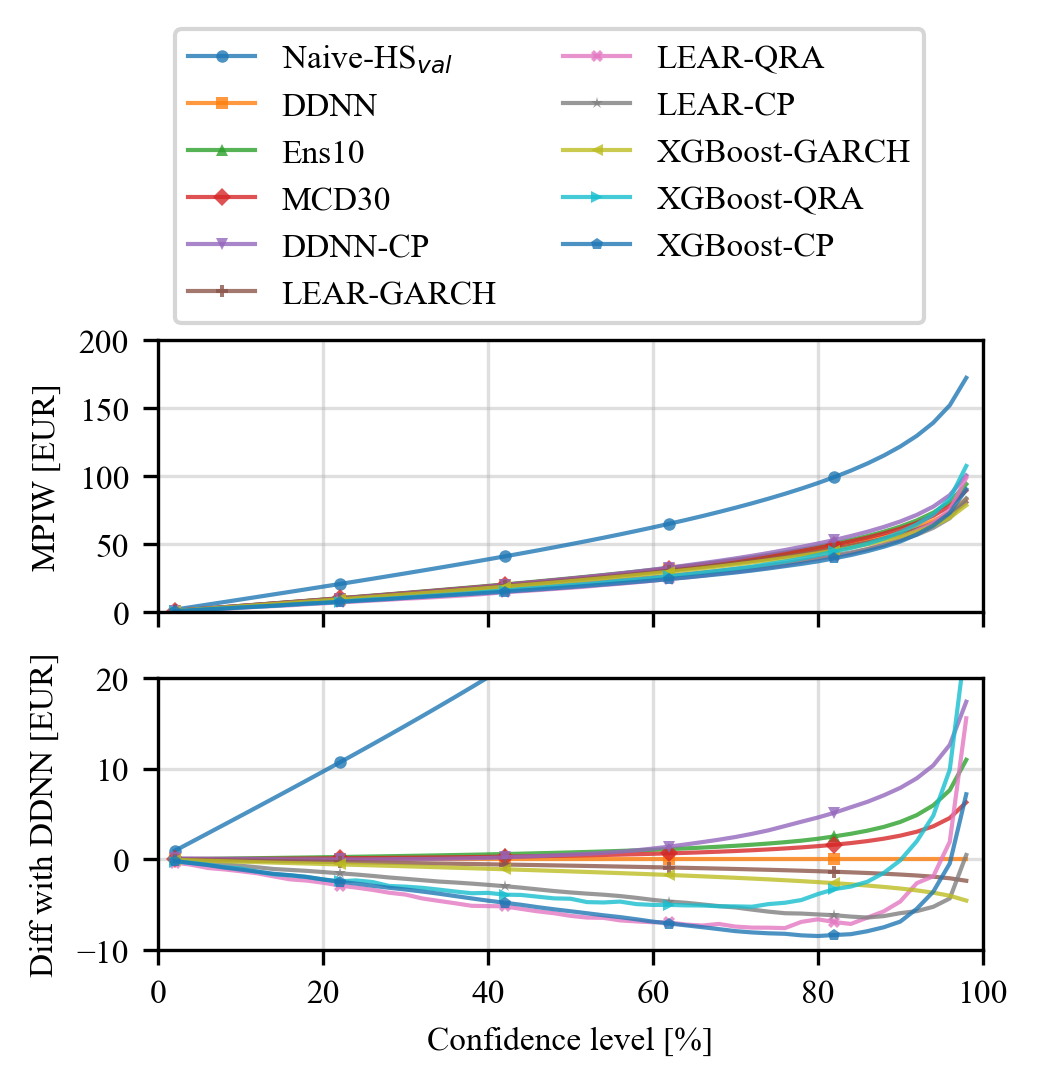

In [19]:
# plot mean prediction interval width
figsize = set_size(height_pad=1.5)
fig, ax = plt.subplots(
    2, 1, figsize=figsize, sharex=True, gridspec_kw={"height_ratios": [1, 1]}
)

lw = 1
for model in models_dict:
    ax[0].plot(
        confidence_levels * 100,
        model["mpiw_mean"],
        label=model["model_name"],
        alpha=0.8,
        lw=lw,
    )

ax[0].set_xlim(0, 100)
ax[0].set_ylim(0, 200)
ax[0].grid(alpha=0.4)
ax[1].set_xlabel("Confidence level [%]")
ax[0].set_ylabel("MPIW [EUR]")
# ax[0].legend(ncols=2)
ax[0].legend(
    loc="lower left",
    ncol=2,
    bbox_to_anchor=(0, 1),
)

# # add second y-axis
# ax2 = ax[0].twinx()
# # plot std
# ax2.set_ylim(0, 40)
# ax2.set_ylabel("std [EUR]")
# ax2.grid(False)
# for model in models_dict:
#     ax2.plot(
#         confidence_levels * 100,
#         model["mpiw_std"],
#         label=model["model_name"],
#         alpha=0.8,
#         linestyle=":",
#         lw=lw,
#     )

model_ddnn = [model for model in models_dict if model["model_name"] == "DDNN"][0]
for i, model in enumerate(models_dict):
    ax[1].plot(
        confidence_levels * 100,
        (model["mpiw_mean"] - model_ddnn["mpiw_mean"]),
        label=model["model_name"],
        alpha=0.8,
        lw=lw,
        color=f"C{i}",
        marker=markers[i],
    )
ax[1].set_xlim(0, 100)
ax[1].set_ylim(-10, 20)
ax[1].set_ylabel("Diff with DDNN [EUR]")
ax[1].grid(alpha=0.4)

plt.tight_layout()
if pgf_backend:
    plt.savefig(
        "plots/" + figure_str + "results_point_interval_mpiw_and_diff.pdf",
        bbox_inches="tight",
        dpi=dpi,
    )
# plt.show()

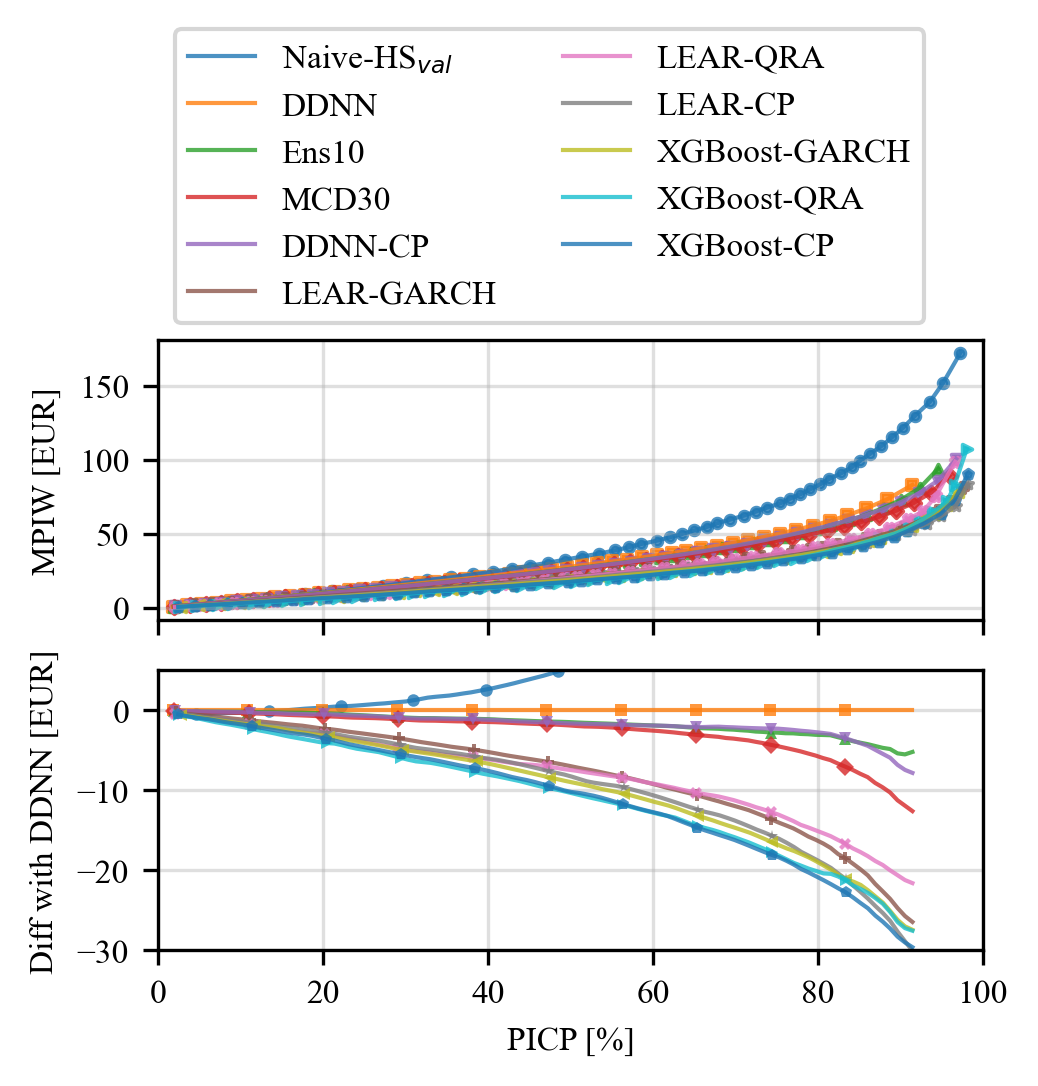

In [ ]:
# plot mean prediction interval width
figsize = set_size(height_pad=1.5)
fig, ax = plt.subplots(
    2, 1, figsize=figsize, sharex=True, gridspec_kw={"height_ratios": [1, 1]}
)

lw = 1
for i, model in enumerate(models_dict):
    ax[0].plot(
        model["coverage_mean"] * 100,
        model["mpiw_mean"],
        label=model["model_name"],
        marker="",
        color=f"C{i}",
        # markersize=2,
        alpha=0.8,
        lw=lw,
    )
    ax[0].scatter(
        model["coverage_mean"] * 100,
        model["mpiw_mean"],
        color=f"C{i}",
        s=5,
        alpha=0.8,
        marker=markers[i],
        rasterized=True,
    )


ax[0].set_xlim(0, 100)
# ax.set_ylim(0, 200)
ax[0].grid(alpha=0.4)
ax[1].set_xlabel("PICP [%]")
ax[0].set_ylabel("MPIW [EUR]")
# ax[0].legend(ncols=2)
ax[0].legend(
    loc="lower left",
    ncol=2,
    bbox_to_anchor=(0, 1),
)

# # add second y-axis
# ax2 = ax[0].twinx()
# # plot std
# ax2.set_ylim(0, 40)
# ax2.set_ylabel("std [EUR]")
# ax2.grid(False)
# for model in models_dict:
#     ax2.plot(
#         model["coverage_mean"] * 100,
#         model["mpiw_std"],
#         label=model["model_name"],
#         alpha=0.8,
#         linestyle=":",
#         lw=lw,
#     )

model_ddnn = [model for model in models_dict if model["model_name"] == "DDNN"][0]
for i, model in enumerate(models_dict):
    picp_lbound = np.max(
        [np.min(model["coverage_mean"]), np.min(model_ddnn["coverage_mean"])]
    )
    picp_ubound = np.min(
        [np.max(model["coverage_mean"]), np.max(model_ddnn["coverage_mean"])]
    )

    # interpolate the values
    picp_interp = np.linspace(picp_lbound, picp_ubound, 100)
    model_interp = np.interp(picp_interp, model["coverage_mean"], model["mpiw_mean"])
    model_ddnn_interp = np.interp(
        picp_interp, model_ddnn["coverage_mean"], model_ddnn["mpiw_mean"]
    )

    ax[1].plot(
        picp_interp * 100,
        (model_interp - model_ddnn_interp),
        label=model["model_name"],
        marker=markers[i],
        color=f"C{i}",
        # markersize=2,
        alpha=0.8,
        lw=lw,
    )
    # ax[1].scatter(
    #     picp_interp * 100,
    #     (model_interp - model_ddnn_interp),
    #     color=f"C{i}",
    #     s=5,
    #     alpha=0.8,
    #     marker=markers[i],
    #     rasterized=True,
    # )

ax[1].set_xlim(0, 100)
ax[1].set_ylim(-30, 5)
ax[1].set_ylabel("Diff with DDNN [EUR]")
ax[1].grid(alpha=0.4)

plt.tight_layout()
if pgf_backend:
    plt.savefig(
        "plots/" + figure_str + "results_point_interval_picp_mpiw_and_diff.pdf",
        bbox_inches="tight",
        dpi=dpi,
    )
# plt.show()